<a href="https://colab.research.google.com/github/aditi2-bsa/SEA800-AI-Text-Detection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Exploratory Data Analysis
**SEA 820 Final Project: Detecting AI-Generated Text**

Team: Aditi & Victoria

This notebook downloads the [AI vs Human Text dataset](https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text) from Kaggle and performs exploratory data analysis to inform our preprocessing and modeling decisions.

**Goals:**
1. Load and validate the dataset (size, columns, missing values)
2. Examine class balance between human (0) and AI-generated (1) text
3. Compare text length distributions across classes
4. Check for duplicates and low-quality samples
5. Identify vocabulary differences between the two classes

In [1]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d shanegerami/ai-vs-human-text
!unzip -q ai-vs-human-text.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text
License(s): other
100% 350M/350M [00:03<00:00, 102MB/s]



In [3]:
import pandas as pd

df = pd.read_csv("AI_Human.csv")
df['generated'] = df['generated'].astype('int8')  # downcast label: saves memory, cleaner 0/1 labels
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['generated'].value_counts())
df.head()

Shape: (487235, 2)

Class distribution:
generated
0    305797
1    181438
Name: count, dtype: int64


,text,generated
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0
3,How often do you ride in a car? Do you drive a...,0
4,Cars are a wonderful thing. They are perhaps o...,0


**Observations:**
- The dataset contains **487,235 samples** with no missing values.
- Labels: `0.0` = human-written, `1.0` = AI-generated.
- The classes are **imbalanced**: ~63% human (305,797) vs ~37% AI (181,438).
  This means accuracy alone is a misleading metric — a trivial model that always
  predicts "human" would score ~63%. We will therefore report **precision, recall,
  and F1-score** for all models.
- Early rows suggest texts are grouped by essay topic (e.g., several essays about cars),
  consistent with the dataset being built from student essay prompts.

## 3. Text Length Analysis

Do human and AI texts differ in length? This affects:
- **Preprocessing:** whether we should filter very short texts
- **Transformer input:** DistilBERT truncates at 512 tokens, so we need to know how much text gets cut
- **Potential leakage:** if length alone separates the classes, models may learn length rather than style

           char_len                                                         \
              count    mean     std   min     25%     50%     75%      max   
generated                                                                    
0          305797.0  2354.6  1082.0  82.0  1543.0  2156.0  2920.0  18322.0   
1          181438.0  2126.3   787.3   1.0  1654.0  2048.0  2480.0   8871.0   

           word_len                                                   
              count   mean    std   min    25%    50%    75%     max  
generated                                                             
0          305797.0  422.4  186.9  14.0  282.0  390.0  520.0  1668.0  
1          181438.0  344.8  117.0   1.0  274.0  337.0  404.0  1239.0  


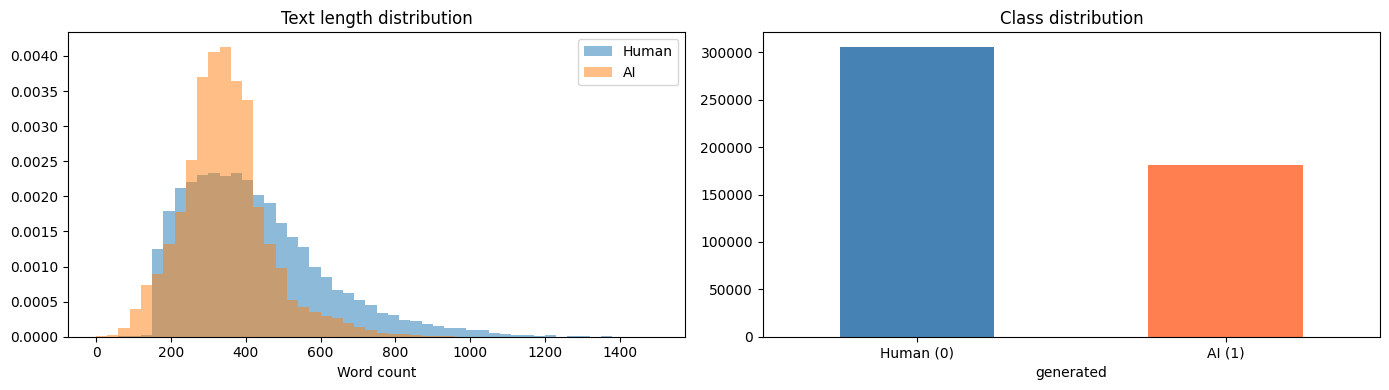

In [4]:
import matplotlib.pyplot as plt

# str.count used instead of str.split to avoid RAM spike on full 487k dataset
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.count(r'\s+') + 1

print(df.groupby('generated')[['char_len', 'word_len']].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for label, name in [(0, 'Human'), (1, 'AI')]:
    subset = df[df['generated'] == label]['word_len']
    ax[0].hist(subset, bins=50, range=(0, 1500), alpha=0.5, label=name, density=True)
ax[0].set_xlabel('Word count'); ax[0].set_title('Text length distribution'); ax[0].legend()

df['generated'].value_counts().plot(kind='bar', ax=ax[1], color=['steelblue', 'coral'])
ax[1].set_xticklabels(['Human (0)', 'AI (1)'], rotation=0)
ax[1].set_title('Class distribution')
plt.tight_layout(); plt.savefig('eda_length_class.png', dpi=150)
plt.show()

**Observations:**
- Human texts: median 390 words (std 187). AI texts: median 337 words (std 117).
  AI-generated text is noticeably more uniform in length; human writing varies far more.
- The AI class contains degenerate samples (minimum length: 1 word / 1 character),
  while the shortest human text is 14 words. A minimum-length filter is justified.
- DistilBERT's 512-token limit corresponds to roughly ~400 words, so a substantial
  fraction of texts (disproportionately human ones) will be truncated during fine-tuning.
  We note this as a potential source of bias in the transformer's view of the data.

In [5]:
print("Exact duplicate texts:", df['text'].duplicated().sum())
print("Very short texts (<20 words):", (df['word_len'] < 20).sum())
df[df['word_len'] < 20].head(10)

Exact duplicate texts: 0
Very short texts (<20 words): 36


,text,generated,char_len,word_len
2380,Code]\n[Email Address]\n[Phone Number],1,36,5
2381,]\n\n[Email]\n\n[Phone Number],1,26,4
2384,],1,1,1
2385,]\n[Email]\n[Phone Number],1,24,4
2388,]\n[Email Address]\n[Phone Number],1,32,5
28737,Facial action coding,1,21,4
29318,Community service is an integral part of ever...,1,90,15
29331,Community service.,1,19,3
29337,Community service refers to the activities an...,1,80,12
29374,"Write an essay on the topic ""A Cowboy Who Rod...",1,59,13


**Decisions:**
- Exact duplicates: **0** — no deduplication needed.
- Texts under 20 words: **36**, all in the AI class. Inspection shows these are
  generation artifacts: template placeholders (e.g., "[Email Address] [Phone Number]"),
  stray brackets, and leaked prompt instructions ("Write an essay on the topic...").
  **Action: remove all texts under 20 words** (36 rows, 0.007% of data).
  These are noise, and their presence only in the AI class could teach a model a
  spurious shortcut ("broken text = AI").

These filters are applied in the preprocessing pipeline (notebook 02).

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

sample = df.groupby('generated').sample(20000, random_state=42)
cv = CountVectorizer(stop_words='english', max_features=5000)
X = cv.fit_transform(sample['text'])
words = np.array(cv.get_feature_names_out())

human_freq = np.asarray(X[(sample['generated']==0).values].mean(axis=0)).flatten()
ai_freq = np.asarray(X[(sample['generated']==1).values].mean(axis=0)).flatten()
ratio = (ai_freq + 1e-9) / (human_freq + 1e-9)

print("Words most associated with AI text:\n", words[np.argsort(ratio)[-25:]])
print("\nWords most associated with human text:\n", words[np.argsort(ratio)[:25]])

Words most associated with AI text:
 ['ekman' 'equitable' 'dictionaries' 'zoos' 'fostering' 'mindfulness'
 'fourier' 'nuances' 'magellan' 'policymakers' 'threader' 'contexts'
 'symmetrical' 'venera' 'testament' 'criticisms' 'enigmatic' 'biteable'
 'vegetarian' 'oxides' 'protections' 'disproportionate' 'hillary'
 'sustainability' 'zip']

Words most associated with human text:
 ['driveless' 'teacher_name' 'idaho' 'gavin' 'proper_name' 'fencing'
 'kerry' 'unrwa' 'survivable' 'acropolis' 'pharaoh' 'jpl' 'bloomed'
 'carbide' 'whittling' 'wreck' 'wrecks' 'school_name' 'micrograms'
 'gondola' '83' '147' 'wont' 'ascertainment' 'fray']


**Observations:**
- **AI-associated vocabulary** is dominated by formal, abstract "essay-speak":
  *equitable, fostering, nuances, policymakers, sustainability, disproportionate*.
  This matches the known register of LLM output. (Some entries like *fourier* or
  *venera* reflect topic differences between the classes rather than style —
  a form of topic leakage worth remembering during error analysis.)
- **Human-associated vocabulary** reveals three signals:
  1. *Anonymization placeholders* (`teacher_name`, `school_name`, `proper_name`) —
     the human essays were scrubbed of personal details before release. These tokens
     never appear in AI text, giving models a **spurious shortcut**: "contains a
     placeholder → human". This is a dataset artifact, not a property of human writing.
  2. *Spelling errors and informal forms* (`driveless`, `wont`) — humans make
     mistakes; LLM output is nearly typo-free.
  3. *Specific numerals* (`83`, `147`, `micrograms`) — human writers cite concrete
     figures more often.
- **Implication:** our models may achieve high scores partly by exploiting artifacts
  (placeholders, typos) rather than deep stylistic understanding. We will revisit this
  in the error analysis and ethics discussion — e.g., a detector keying on typos would
  systematically misclassify careful writers, and one keying on placeholders would not
  generalize outside this dataset.

## 6. Summary of EDA Findings

| Finding | Implication for modeling |
|---|---|
| Class imbalance: 63% human / 37% AI | Report precision/recall/F1; stratified splits |
| AI texts more uniform in length (std 117 vs 187) | Length itself is weakly predictive |
| ~Half of texts exceed DistilBERT's 512-token limit | Truncation disproportionately affects human texts |
| 0 duplicates; 36 junk texts (<20 words, all AI) | Filter texts under 20 words |
| Anonymization tokens only in human class | Spurious shortcut risk — flag in error analysis |
| Typos/informal spelling mark human text | Potential bias against careful/non-native writers |

**Next:** `02_baseline_tfidf.ipynb` — filtering, stratified split, TF-IDF + Logistic Regression baseline.